In [1]:
# Cell 1: Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Mengatur tampilan pandas agar semua kolom terlihat saat di-print
pd.set_option('display.max_columns', None)

# Load data
file_path = r"C:\ML(Machine Learning\UTSML\Data_Gizi_MBG_SMP (1).xlsx"
df = pd.read_excel(file_path, sheet_name='Data Siswa')

print("Data berhasil dimuat!")
print(f"Dimensi dataset: {df.shape[0]} baris dan {df.shape[1]} kolom.")

Data berhasil dimuat!
Dimensi dataset: 1000 baris dan 32 kolom.


In [2]:
# Cell 2: EDA - Inspeksi Dasar
print("=== 5 Baris Pertama Dataset ===")
display(df.head())

print("\n=== Informasi Tipe Data & Missing Values ===")
df.info()

print("\n=== Statistik Deskriptif (Kolom Numerik) ===")
display(df.describe())

=== 5 Baris Pertama Dataset ===


,ID Siswa,Nama,Jenis Kelamin,Usia,Kelas,Berat Badan kg,Tinggi Badan cm,IMT,Kategori IMT,LILA cm,Riwayat Stunting,Hemoglobin gdL,Status Anemia,Level Aktivitas,PAL,Ekskul,Durasi Aktivitas jam,Alergi Makanan,Penyakit Kronis,Intoleransi Laktosa,Pola Makan,Kebiasaan Sarapan,Pantangan Makanan,Tingkat Ekonomi,Asupan Gizi di Rumah,BMR kkal,Kebutuhan Kalori kkal,Kebutuhan Protein g,Kebutuhan Karbohidrat g,Kebutuhan Lemak g,Kebutuhan Serat g,Kelompok Gizi
0,SMP0001,Eko Pratama,Laki-laki,15,9,54.2,168.5,19.09,Normal,19.4,Ya,14.1,Normal,Sangat Ringan,1.200,OSIS,1.2,Tidak Ada,Asma,Tidak,3x/hari,Selalu,Tidak Ada,Menengah,Kurang,1538,1846,46.1,253.8,61.5,32.7,Kelompok A – Gizi Kurang (Penguatan)
1,SMP0002,Indah Kusuma,Perempuan,14,8,44.7,162.5,16.93,Kurus,19.8,Tidak,15.3,Normal,Ringan,1.375,Olahraga,3.5,Tidak Ada,Tidak Ada,Tidak,2x/hari,Selalu,Tidak Makan Daging Babi,Rendah,Cukup,1304,2062,38.0,283.5,68.7,31.1,Kelompok A – Gizi Kurang (Penguatan)
2,SMP0003,Hana Wijaya,Perempuan,15,9,52.6,159.6,20.65,Normal,28.0,Ya,12.5,Normal,Ringan,1.375,Pramuka,1.4,Telur,Tidak Ada,Tidak,3x/hari,Kadang-kadang,Tidak Ada,Menengah,Baik,1363,1874,44.7,257.7,62.5,34.6,Kelompok A – Gizi Kurang (Penguatan)
3,SMP0004,Dewi Kurniawan,Perempuan,15,9,57.9,154.0,24.41,Normal,20.2,Ya,13.1,Normal,Sedang,1.550,Olahraga,1.3,Susu/Laktosa,Tidak Ada,Tidak,2x/hari,Selalu,Tidak Makan Daging Babi,Menengah Atas,Cukup,1395,2162,49.2,297.3,72.1,32.5,Kelompok A – Gizi Kurang (Penguatan)
4,SMP0005,Toni Santoso,Laki-laki,13,7,39.0,155.0,16.23,Kurus,19.5,Tidak,13.1,Normal,Sangat Ringan,1.200,Futsal/Basket,2.2,Gluten,Tidak Ada,Tidak,2x/hari,Kadang-kadang,Tidak Ada,Menengah Atas,Kurang,1281,1768,33.2,243.1,58.9,23.0,Kelompok A – Gizi Kurang (Penguatan)



=== Informasi Tipe Data & Missing Values ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID Siswa                 1000 non-null   str    
 1   Nama                     1000 non-null   str    
 2   Jenis Kelamin            1000 non-null   str    
 3   Usia                     1000 non-null   int64  
 4   Kelas                    1000 non-null   int64  
 5   Berat Badan kg           1000 non-null   float64
 6   Tinggi Badan cm          1000 non-null   float64
 7   IMT                      1000 non-null   float64
 8   Kategori IMT             1000 non-null   str    
 9   LILA cm                  1000 non-null   float64
 10  Riwayat Stunting         1000 non-null   str    
 11  Hemoglobin gdL           1000 non-null   float64
 12  Status Anemia            1000 non-null   str    
 13  Level Aktivitas          1000 non-null   str

,Usia,Kelas,Berat Badan kg,Tinggi Badan cm,IMT,LILA cm,Hemoglobin gdL,PAL,Durasi Aktivitas jam,BMR kkal,Kebutuhan Kalori kkal,Kebutuhan Protein g,Kebutuhan Karbohidrat g,Kebutuhan Lemak g,Kebutuhan Serat g
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,13.975000,7.975000,48.679900,159.060000,19.271730,22.908600,12.706500,1.505725,2.278700,1383.836000,2154.494000,41.376400,296.245500,71.81550,28.621200
std,0.810575,0.810575,8.957916,7.410914,3.490104,3.068818,1.242695,0.176916,1.015711,138.170258,316.252778,7.614651,43.485366,10.54125,3.830977
min,13.000000,7.000000,26.100000,137.500000,9.760000,14.000000,9.100000,1.200000,0.500000,1078.000000,1391.000000,22.200000,191.300000,46.40000,22.000000
25%,13.000000,7.000000,42.600000,154.000000,16.870000,20.800000,11.900000,1.375000,1.400000,1280.000000,1914.750000,36.200000,263.275000,63.80000,25.300000
50%,14.000000,8.000000,48.500000,159.050000,19.180000,22.900000,12.600000,1.550000,2.300000,1364.000000,2133.500000,41.200000,293.350000,71.10000,28.600000
75%,15.000000,9.000000,54.500000,164.100000,21.565000,24.800000,13.500000,1.550000,3.200000,1470.000000,2382.000000,46.300000,327.500000,79.40000,31.825000
max,15.000000,9.000000,81.400000,185.000000,35.620000,32.700000,16.700000,1.900000,4.000000,1937.000000,3059.000000,69.200000,420.600000,102.00000,35.000000


=== Jumlah Missing Value per Kolom ===
Series([], dtype: int64)

=== Distribusi Kelas Target (Kelompok Gizi) ===
Kelompok Gizi
Kelompok A – Gizi Kurang (Penguatan)    460
Kelompok E – Gizi Normal                239
Kelompok C – Kondisi Khusus             204
Kelompok D – Aktivitas Tinggi            57
Kelompok B – Gizi Lebih (Pembatasan)     40
Name: count, dtype: int64


C:\Users\Acer\AppData\Local\Temp\ipykernel_5808\3157201584.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=target_counts.index, x=target_counts.values, palette="viridis")


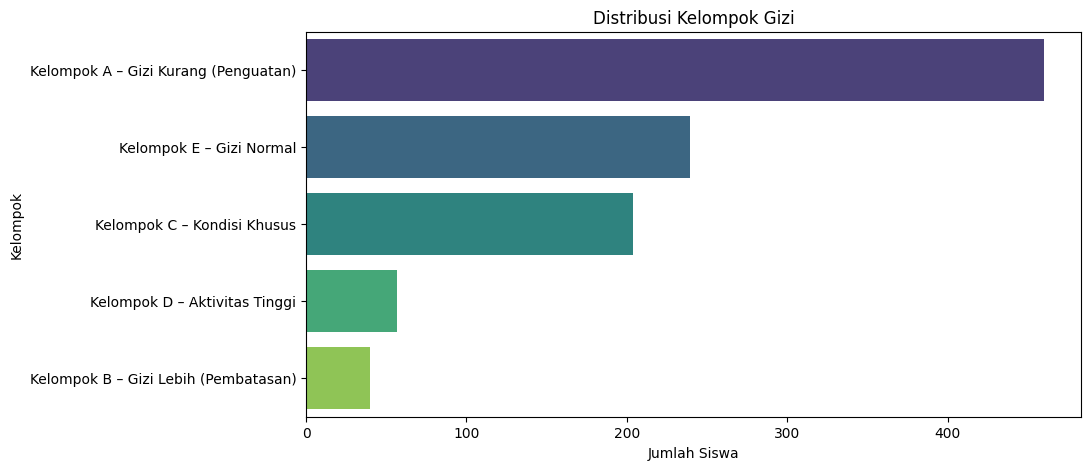

In [3]:
# Cell 3: EDA - Kualitas Data dan Target
print("=== Jumlah Missing Value per Kolom ===")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0]) # Hanya menampilkan yang ada missing value

print("\n=== Distribusi Kelas Target (Kelompok Gizi) ===")
target_counts = df['Kelompok Gizi'].value_counts()
print(target_counts)

plt.figure(figsize=(10, 5))
sns.barplot(y=target_counts.index, x=target_counts.values, palette="viridis")
plt.title("Distribusi Kelompok Gizi")
plt.xlabel("Jumlah Siswa")
plt.ylabel("Kelompok")
plt.show()

In [4]:
# Cell 4: Drop fitur identifier
# ID Siswa dan Nama tidak membawa pola untuk dipelajari Machine Learning
df_clean = df.drop(columns=['ID Siswa', 'Nama'])

# Memisahkan Fitur (X) dan Target (y)
X = df_clean.drop(columns=['Kelompok Gizi'])
y = df_clean['Kelompok Gizi']

print("Dimensi Fitur (X):", X.shape)
print("Dimensi Target (y):", y.shape)

Dimensi Fitur (X): (1000, 29)
Dimensi Target (y): (1000,)


In [5]:
# Cell 5: Encoding Kategorikal & Target
# 1. Encoding Target (y) menjadi integer (0, 1, 2, 3, 4)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 2. Encoding Fitur (X)
# Menggunakan One-Hot Encoding untuk kolom bertipe 'object'
# drop_first=True digunakan untuk menghindari jebakan Multikolinearitas (Dummy Variable Trap)
X_encoded = pd.get_dummies(X, drop_first=True)

print("Jumlah kolom fitur setelah One-Hot Encoding:", X_encoded.shape[1])
display(X_encoded.head())

Jumlah kolom fitur setelah One-Hot Encoding: 55


,Usia,Kelas,Berat Badan kg,Tinggi Badan cm,IMT,LILA cm,Hemoglobin gdL,PAL,Durasi Aktivitas jam,BMR kkal,Kebutuhan Kalori kkal,Kebutuhan Protein g,Kebutuhan Karbohidrat g,Kebutuhan Lemak g,Kebutuhan Serat g,Jenis Kelamin_Perempuan,Kategori IMT_Kurus,Kategori IMT_Normal,Kategori IMT_Obesitas,Kategori IMT_Sangat Kurus,Riwayat Stunting_Ya,Status Anemia_Anemia Ringan,Status Anemia_Normal,Level Aktivitas_Ringan,Level Aktivitas_Sangat Berat,Level Aktivitas_Sangat Ringan,Level Aktivitas_Sedang,Ekskul_OSIS,Ekskul_Olahraga,Ekskul_PMR,Ekskul_Pramuka,Ekskul_Seni/Musik,Ekskul_Tidak Ada,Alergi Makanan_Kacang,Alergi Makanan_Seafood,Alergi Makanan_Susu/Laktosa,Alergi Makanan_Telur,Alergi Makanan_Tidak Ada,Penyakit Kronis_Diabetes Tipe 1,Penyakit Kronis_Hipertensi,Penyakit Kronis_Maag,Penyakit Kronis_Tidak Ada,Intoleransi Laktosa_Ya,Pola Makan_2x/hari,Pola Makan_3x/hari,Pola Makan_>3x/hari,Kebiasaan Sarapan_Selalu,Kebiasaan Sarapan_Tidak Pernah,Pantangan Makanan_Tidak Makan Daging Babi,Pantangan Makanan_Tidak Makan Seafood,Pantangan Makanan_Vegetarian,Tingkat Ekonomi_Menengah Atas,Tingkat Ekonomi_Rendah,Asupan Gizi di Rumah_Cukup,Asupan Gizi di Rumah_Kurang
0,15,9,54.2,168.5,19.09,19.4,14.1,1.200,1.2,1538,1846,46.1,253.8,61.5,32.7,False,False,True,False,False,True,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True
1,14,8,44.7,162.5,16.93,19.8,15.3,1.375,3.5,1304,2062,38.0,283.5,68.7,31.1,True,True,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,True,False,True,False,False,False,True,True,False
2,15,9,52.6,159.6,20.65,28.0,12.5,1.375,1.4,1363,1874,44.7,257.7,62.5,34.6,True,False,True,False,False,True,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False
3,15,9,57.9,154.0,24.41,20.2,13.1,1.550,1.3,1395,2162,49.2,297.3,72.1,32.5,True,False,True,False,False,True,False,True,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,True,False,False,True,False,True,False
4,13,7,39.0,155.0,16.23,19.5,13.1,1.200,2.2,1281,1768,33.2,243.1,58.9,23.0,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,True


In [6]:
# Cell 6: Data Splitting & Scaling

# 1. Train-Test Split (80% Train, 20% Test)
# stratify=y_encoded dipasang karena dari Cell 3 kita tahu datanya imbalanced
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Jumlah data latih:", X_train.shape[0])
print("Jumlah data uji:", X_test.shape[0])

# 2. Feature Scaling
# Mengambil nama-nama kolom numerik asli yang butuh discale (bukan kolom hasil one-hot encoding)
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
# Fit DAN transform hanya pada data training
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
# Hanya transform pada data test (menggunakan pattern dari training)
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("\nData berhasil distandarisasi!")

Jumlah data latih: 800
Jumlah data uji: 200

Data berhasil distandarisasi!


In [7]:
# Cell 7: Melatih Model
# Kita siapkan dictionary untuk menyimpan model
models = {
    "Baseline (Dummy)": DummyClassifier(strategy='stratified', random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Dictionary untuk menyimpan prediksi tiap model
predictions = {}

print("Melatih model...")
for name, model in models.items():
    model.fit(X_train, y_train)          # Proses belajar
    y_pred = model.predict(X_test)       # Proses memprediksi data uji
    predictions[name] = y_pred
    print(f"[V] {name} selesai dilatih.")

Melatih model...
[V] Baseline (Dummy) selesai dilatih.
[V] Logistic Regression selesai dilatih.
[V] Random Forest selesai dilatih.


In [8]:
# Cell 8: Evaluasi dan Interpretasi

print("=== PERBANDINGAN PERFORMA MODEL ===")
for name, y_pred in predictions.items():
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted') # weighted karena kelas imbalanced
    print(f"Model: {name}")
    print(f"  - Accuracy : {acc:.4f}")
    print(f"  - F1-Score : {f1:.4f}\n")

print("=== CLASSIFICATION REPORT (RANDOM FOREST) ===")
# Mengembalikan nilai integer prediksi ke nama kelas aslinya
print(classification_report(y_test, predictions["Random Forest"], target_names=label_encoder.classes_))

# === Feature Importance Extract ===
# Melihat fitur apa yang paling berpengaruh secara gizi bagi algoritma Random Forest
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({
    "Fitur": X_encoded.columns, 
    "Tingkat Kepentingan": importances
}).sort_values(by="Tingkat Kepentingan", ascending=False)

print("=== TOP 10 FITUR PALING BERPENGARUH ===")
display(feature_imp_df.head(10))

=== PERBANDINGAN PERFORMA MODEL ===
Model: Baseline (Dummy)
  - Accuracy : 0.3350
  - F1-Score : 0.3258

Model: Logistic Regression
  - Accuracy : 1.0000
  - F1-Score : 1.0000

Model: Random Forest
  - Accuracy : 1.0000
  - F1-Score : 1.0000

=== CLASSIFICATION REPORT (RANDOM FOREST) ===
                                      precision    recall  f1-score   support

Kelompok A – Gizi Kurang (Penguatan)       1.00      1.00      1.00        92
Kelompok B – Gizi Lebih (Pembatasan)       1.00      1.00      1.00         8
         Kelompok C – Kondisi Khusus       1.00      1.00      1.00        41
       Kelompok D – Aktivitas Tinggi       1.00      1.00      1.00        11
            Kelompok E – Gizi Normal       1.00      1.00      1.00        48

                            accuracy                           1.00       200
                           macro avg       1.00      1.00      1.00       200
                        weighted avg       1.00      1.00      1.00       200

=== TO

,Fitur,Tingkat Kepentingan
20,Riwayat Stunting_Ya,0.165380
4,IMT,0.132284
37,Alergi Makanan_Tidak Ada,0.105231
17,Kategori IMT_Normal,0.095585
41,Penyakit Kronis_Tidak Ada,0.048786
2,Berat Badan kg,0.047015
7,PAL,0.043564
11,Kebutuhan Protein g,0.037174
9,BMR kkal,0.024944
10,Kebutuhan Kalori kkal,0.023138
